In [1]:
from pathlib import Path
import urllib.request

model_dir = Path("./models/yunet")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "face_detection_yunet_2023mar.onnx"

if not model_path.exists():
    url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
    urllib.request.urlretrieve(url, model_path)

print("Model:", model_path.resolve())

Model: /home/saheb_sub/Desktop/DL/Face-Recognition-Model/models/yunet/face_detection_yunet_2023mar.onnx


In [ ]:
import cv2

model_path = "./models/yunet/face_detection_yunet_2023mar.onnx"
detector = cv2.FaceDetectorYN.create(
    model_path,
    "",
    (320, 320),
    0.6,
    0.3,
    50
)

In [ ]:
from PIL import Image
image = cv2.imread("Your_image_path")


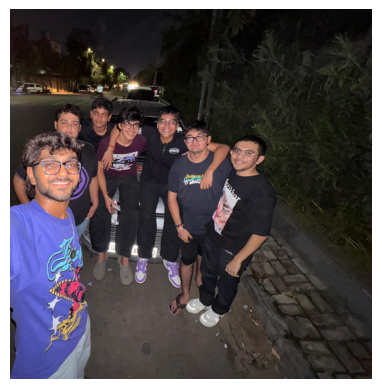

In [6]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [7]:
h,w = image.shape[:2]
detector.setInputSize((w,h))
_, faces = detector.detect(image)
print(faces)

[[1.6722954e+03 9.8972931e+02 1.9916061e+02 2.1769841e+02 1.7219117e+03
  1.0737437e+03 1.8087451e+03 1.0874836e+03 1.7514110e+03 1.1265173e+03
  1.7095129e+03 1.1446169e+03 1.7870277e+03 1.1570862e+03 9.4181031e-01]
 [1.1182948e+03 7.8249432e+02 1.4468037e+02 1.8212036e+02 1.1591011e+03
  8.4297333e+02 1.2270725e+03 8.5308972e+02 1.1866960e+03 8.8209375e+02
  1.1511125e+03 9.0817285e+02 1.2099868e+03 9.1719330e+02 9.2716688e-01]
 [6.1372095e+02 7.3108429e+02 1.3412636e+02 1.6651099e+02 6.5139862e+02
  7.8923236e+02 7.1219043e+02 7.9710107e+02 6.7627985e+02 8.2875232e+02
  6.4771667e+02 8.4976892e+02 6.9882916e+02 8.5641516e+02 9.2675728e-01]
 [3.6044333e+02 7.7900708e+02 1.6523509e+02 1.9343990e+02 4.1424850e+02
  8.5280573e+02 4.8840277e+02 8.6710339e+02 4.4814551e+02 9.0136298e+02
  4.0654056e+02 9.2304462e+02 4.6560037e+02 9.3584302e+02 9.2301375e-01]
 [1.3243773e+03 8.9541418e+02 1.6577057e+02 1.8933414e+02 1.3650649e+03
  9.7187726e+02 1.4393838e+03 9.7099377e+02 1.4009598e+03 1.

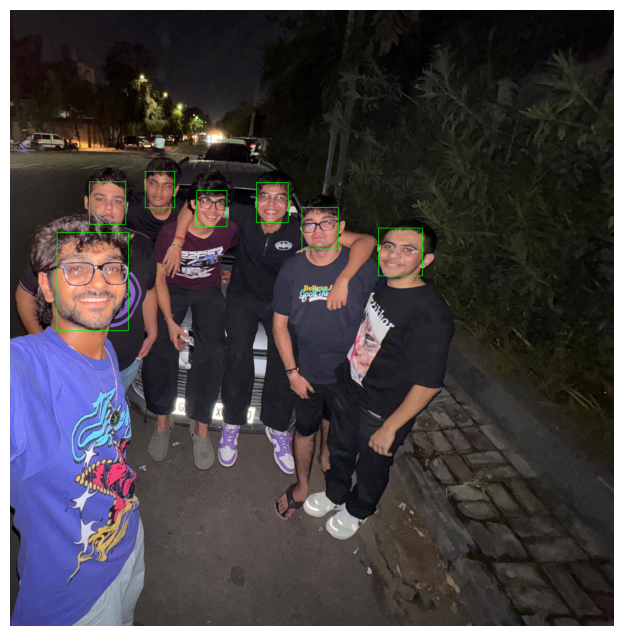

In [8]:
display_image = image.copy()

if faces is not None:

    for face in faces:

        x, y, w, h = face[:4].astype(int)

        cv2.rectangle(
            display_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

plt.figure(figsize=(12, 8))

plt.imshow(
    cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

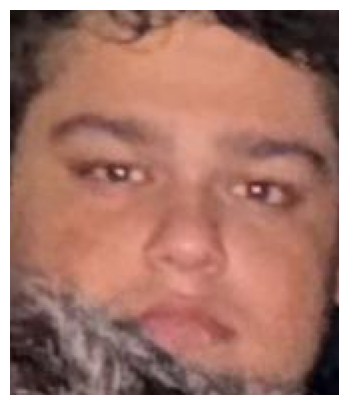

In [10]:
face = faces[3]

x, y, w, h = face[:4].astype(int)

face_crop = image[
    y:y+h,
    x:x+w
]   

plt.figure(figsize=(5, 5))

plt.imshow(
    cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

In [11]:
def crop_face(image, face, padding=0.25):

    x, y, w, h = face[:4].astype(int)

    pad_x = int(w * padding)
    pad_y = int(h * padding)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)

    x2 = min(image.shape[1], x + w + pad_x)
    y2 = min(image.shape[0], y + h + pad_y)

    return image[y1:y2, x1:x2]

Found 7 faces


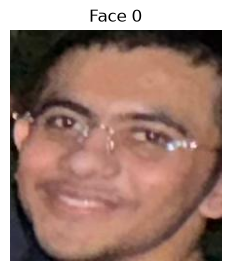

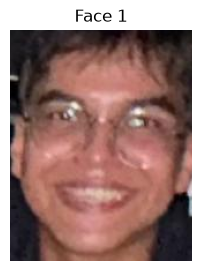

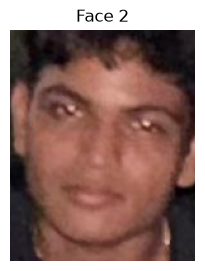

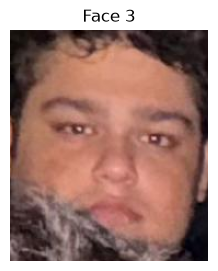

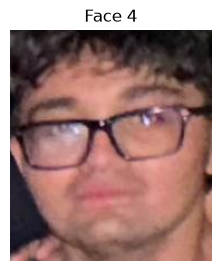

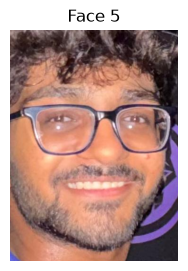

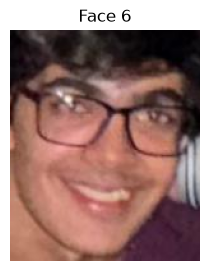

In [15]:
if faces is not None:

    print(f"Found {len(faces)} faces")

    for i, face in enumerate(faces):

        face_crop = crop_face(
            image,
            face,
            padding=0.05
        )

        plt.figure(figsize=(3, 3))

        plt.imshow(
            cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
        )

        plt.title(f"Face {i}")
        plt.axis("off")
        plt.show()